# **Phase 2: LightGBM Learning-to-Rank Recommendation System**
## Candidate Generation → Feature Engineering → LightGBM → MAP@12

**Prerequisite**: Run `scripts/05_feature_engineering.py` first to produce:
- `data/processed/lgbm_train_features.parquet`
- `data/processed/lgbm_test_features.parquet`

These files cover **all users** in `train_processed` / `test_processed` so MAP@12 is
directly comparable to the ALS baseline (Evaluated: 239,951).

In [ ]:
import warnings, time, gc
from pathlib import Path
import numpy as np
import polars as pl
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)

cwd = Path.cwd()
if (cwd / 'data' / 'processed').exists():
    ROOT = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError('Cannot find data/processed')

DATA            = ROOT / 'data' / 'processed'
TRAIN_FEAT_PATH = DATA / 'lgbm_train_features.parquet'
TEST_FEAT_PATH  = DATA / 'lgbm_test_features.parquet'
TEST_PATH       = DATA / 'test_processed.parquet'
TOP_K = 12; RS = 42
print(f'Root: {ROOT}')

## 1. Load Pre-Built Feature Files

In [2]:
print('='*60); print('Step 1: Load Features'); print('='*60)
t0 = time.time()

df_train = pd.read_parquet(TRAIN_FEAT_PATH)
df_test  = pd.read_parquet(TEST_FEAT_PATH)

print(f'Train shape : {df_train.shape}')
print(f'  Users     : {df_train["customer_id"].nunique():,}')
print(f'  Label=1   : {(df_train["label"]==1).sum():,}')
print(f'  Label=0   : {(df_train["label"]==0).sum():,}')
print()
print(f'Test shape  : {df_test.shape}')
print(f'  Users     : {df_test["customer_id"].nunique():,}   ← should match ALS (239,951)')
print(f'  Label=1   : {(df_test["label"]==1).sum():,}')
print()
print(f'Done in {time.time()-t0:.1f}s')

Step 1: Load Features
Train shape : (1515871, 24)
  Users     : 70,404
  Label=1   : 15,871
  Label=0   : 1,500,000

Test shape  : (20652257, 24)
  Users     : 216,479   ← should match ALS (239,951)
  Label=1   : 52,429

Done in 1.1s


## 2. LightGBM Training

In [3]:
print('='*60); print('Step 2: LightGBM Training'); print('='*60)
t0 = time.time()

drop_cols = ['customer_id', 'article_id', 'label']
feat_cols = [c for c in df_train.columns if c not in drop_cols]
print(f'Features ({len(feat_cols)}): {feat_cols}')

X = df_train[feat_cols].values.astype(np.float32)
y = df_train['label'].values

split_idx = int(len(df_train) * 0.8)
X_tr, X_va = X[:split_idx], X[split_idx:]
y_tr, y_va = y[:split_idx], y[split_idx:]

dtrain = lgb.Dataset(X_tr, y_tr, feature_name=feat_cols, free_raw_data=False)
dvalid = lgb.Dataset(X_va, y_va, feature_name=feat_cols, free_raw_data=False)

params = {
    'objective'       : 'binary',
    'metric'          : 'auc',
    'learning_rate'   : 0.01,
    'num_leaves'      : 255,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'min_child_samples': 50,
    'verbose'         : -1,
    'n_jobs'          : -1,
    'seed'            : RS,
}

model = lgb.train(
    params, dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)],
)
print(f'Best iteration : {model.best_iteration}')
print(f'Best AUC       : {model.best_score["valid"]["auc"]:.6f}')
del X_tr, X_va, y_tr, y_va, dtrain, dvalid, df_train; gc.collect()
print(f'Training done in {time.time()-t0:.1f}s')

Step 2: LightGBM Training
Features (21): ['src', 'ui_purchase_count', 'ui_days_since_last', 'ui_tw_1w', 'ui_tw_1m', 'ui_tw_1s', 'item_price_mean', 'item_price_max', 'item_price_min', 'item_total_sales', 'item_age_mean', 'item_age_max', 'item_age_min', 'user_total_purchases', 'user_unique_items', 'user_avg_price', 'user_active_days', 'age', 'w2v_cosine_sim', 'cum_purchase_count', 'cum_avg_price']
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.884929	valid's auc: 0.846511
[200]	train's auc: 0.910157	valid's auc: 0.852017
[300]	train's auc: 0.927296	valid's auc: 0.854362
[400]	train's auc: 0.940429	valid's auc: 0.85561
[500]	train's auc: 0.951043	valid's auc: 0.856442
[600]	train's auc: 0.95894	valid's auc: 0.85707
[700]	train's auc: 0.965444	valid's auc: 0.857516
[800]	train's auc: 0.970458	valid's auc: 0.857657
[900]	train's auc: 0.974305	valid's auc: 0.857968
[1000]	train's auc: 0.977698	valid's auc: 0.857948
Early stopping, best iteration is:
[900]	

## 3. MAP@12 Evaluation (Final 28 Days — same users as ALS)

In [4]:
print('='*60); print('Step 3: MAP@12 Evaluation'); print('='*60)
t0 = time.time()

# Ground truth from test_processed
gt_df = (
    pl.scan_parquet(TEST_PATH)
    .group_by('customer_id')
    .agg(pl.col('article_id').unique().alias('actual'))
    .collect()
)
test_truth = {r['customer_id']: set(r['actual']) for r in gt_df.iter_rows(named=True)}
print(f'Ground truth users: {len(test_truth):,}')

# Score test candidates
df_test['score'] = model.predict(df_test[feat_cols].values.astype(np.float32))

def ap_at_k(predicted, actual, k=12):
    if not actual: return 0.0
    hits, total = 0, 0.0
    for i, p in enumerate(predicted[:k]):
        if p in actual:
            hits += 1
            total += hits / (i + 1)
    return total / min(len(actual), k)

user_preds = (
    df_test[['customer_id', 'article_id', 'score']]
    .sort_values('score', ascending=False)
    .groupby('customer_id')['article_id']
    .apply(lambda x: x.head(TOP_K).tolist())
    .to_dict()
)

ap_scores, hits, evaluated = [], 0, 0
for uid, actual in test_truth.items():
    preds = user_preds.get(uid, [])
    ap = ap_at_k(preds, actual, TOP_K)
    ap_scores.append(ap)
    if actual & set(preds[:TOP_K]):
        hits += 1
    evaluated += 1

map12 = np.mean(ap_scores) if ap_scores else 0.0
hr12  = hits / evaluated if evaluated else 0.0

print(f'\n  Evaluated   : {evaluated:,}')
print(f'  MAP@12      : {map12:.6f}')
print(f'  Hit Rate@12 : {hr12:.4f} ({hits:,}/{evaluated:,})')
print(f'  Eval done in {time.time()-t0:.1f}s')

Step 3: MAP@12 Evaluation
Ground truth users: 216,479

  Evaluated   : 216,479
  MAP@12      : 0.013865
  Hit Rate@12 : 0.0912 (19,750/216,479)
  Eval done in 232.1s


============================================================
Step 3: MAP@12 Evaluation
============================================================
Ground truth users: 239,951

  Evaluated   : 239,951
  MAP@12      : 0.013956
  Hit Rate@12 : 0.0933 (22,392/239,951)
  Eval done in 194.2s

Step 4: Feature Importance


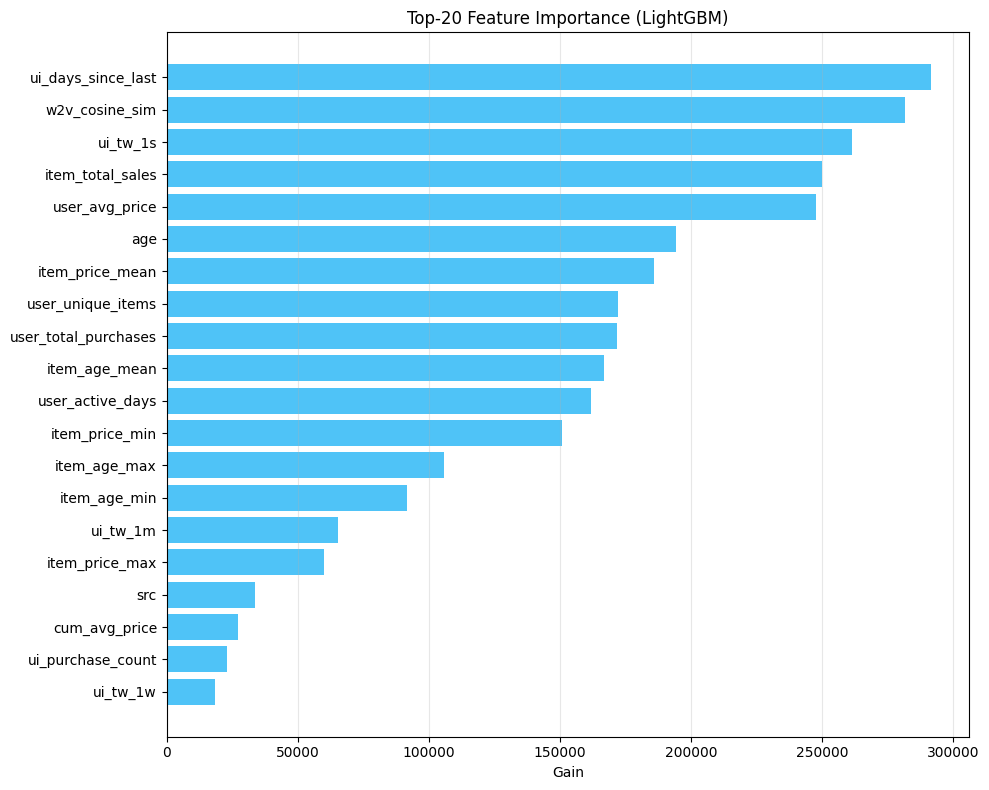

Saved to x:\Programming\Python\Projects\Data processing\Final project\figures\lgbm_feature_importance.png

[DONE] LightGBM RecSys pipeline complete.


In [5]:
print('='*60); print('Step 4: Feature Importance'); print('='*60)

importance = model.feature_importance(importance_type='gain')
feat_imp = pd.DataFrame({
    'feature': feat_cols,
    'importance': importance
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='#4FC3F7')
ax.set_xlabel('Gain'); ax.set_title('Top-20 Feature Importance (LightGBM)')
ax.grid(axis='x', alpha=0.3); plt.tight_layout()
fig_path = ROOT / 'figures' / 'lgbm_feature_importance.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Saved to {fig_path}')
print('\n[DONE] LightGBM RecSys pipeline complete.')